In [12]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
load_dotenv()

True

In [7]:
model=ChatOpenAI(model="gpt-5-mini")

In [8]:
class op(BaseModel):
    feedback:str =Field(description="return the Feedback for the given essay")
    score:int=Field(gt=0, lt=11, description="returns the score")

In [9]:
str_model=model.with_structured_output(op)

In [11]:
class upscstate(TypedDict):
    essay:str
    cot:str
    doa:str
    lang:str
    overall_feedback:str
    indi_score:Annotated[list[int], operator.add]
    avg_score:float



In [33]:
def eval_cot(state: upscstate) -> upscstate:
    essay=state['essay']
    prompt=f'this is the UPSC {essay} and you have to evaluate the essay based on clarity of thought and return a feedback and a score'
    rs=str_model.invoke(prompt)
    feedback=rs.feedback
    return {'cot':feedback, 'indi_score':[rs.score]}



In [34]:
def eval_lang(state: upscstate) -> upscstate:
    essay=state['essay']
    prompt=f'this is an UPSC {essay} and evaluate it on the basis of language quality and return a feedback and a score'
    rs=str_model.invoke(prompt)
    feedback=rs.feedback
    return {'lang':feedback, 'indi_score':[rs.score]}


In [35]:
def eval_doa(state: upscstate) -> upscstate:
    essay=state['essay']
    prompt=f'this is a UPSC {essay} and evaluate it on the basis of depth of analysis and return feedback and a score'
    rs=str_model.invoke(prompt)
    feedback=rs.feedback
    return {'doa':feedback, 'indi_score':[rs.score]}

In [44]:
def final_eval(state: upscstate) -> upscstate:
    essay=state['essay']
    cot=state['cot']
    doa=state['doa']
    lang=state['lang']
    ind_score=state['indi_score']
    prompt="""
You are the final evaluator for a UPSC essay.

You will receive feedback from three independent evaluators:

1. Language Quality Feedback: {lang}
2. Content of Thought Feedback: {cot}
3. Depth of Analysis Feedback: {doa}

Your task is ONLY to synthesize these three feedbacks into one concise overall evaluation.

Instructions:
- Do NOT ask any follow-up questions.
- Do NOT rewrite the essay.
- Do NOT generate a new introduction, conclusion, thesis, or paragraphs.
- Do NOT suggest alternative vocabulary or sentence replacements.
- Do NOT add information that is not present in the three feedbacks.
- Identify the most important strengths of the essay.
- Identify the most important weaknesses.
- Identify the 3–5 highest-priority improvements the candidate should make.
- Resolve overlapping/repeated feedback instead of repeating the same point multiple times.
- Keep the feedback specific to UPSC essay writing.
- Give a balanced evaluation: mention both strengths and weaknesses.
- Be concise and practical.
- Do not provide a line-by-line analysis.

Return ONLY the following structure:

Overall Evaluation:
<2–3 sentence summary of the essay's overall quality>

Strengths:
- <strength>
- <strength>
- <strength>

Weaknesses:
- <weakness>
- <weakness>
- <weakness>

Priority Improvements:
1. <most important improvement>
2. <second most important improvement>
3. <third most important improvement>
4. <optional fourth improvement>
5. <optional fifth improvement>

Overall Verdict:
<short final assessment of the essay>

Language Feedback:
{lang}

Content of Thought Feedback:
{cot}

Depth of Analysis Feedback:
{doa}
"""
    rs=model.invoke(prompt)
    avg=sum(state['indi_score'])/len(state['indi_score'])
    return {'overall_feedback':rs.content, 'avg_score': avg}

In [45]:
graph=StateGraph(upscstate)

graph.add_node('eval_lang', eval_lang)
graph.add_node('eval_cot', eval_cot)
graph.add_node('eval_doa', eval_doa)
graph.add_node('final_eval', final_eval)

graph.add_edge(START, 'eval_lang')
graph.add_edge(START, 'eval_cot')
graph.add_edge(START, 'eval_doa')
graph.add_edge('eval_lang', 'final_eval')
graph.add_edge('eval_cot', 'final_eval')
graph.add_edge('eval_doa', 'final_eval')
graph.add_edge('final_eval',END)


In [38]:
wf=graph.compile()

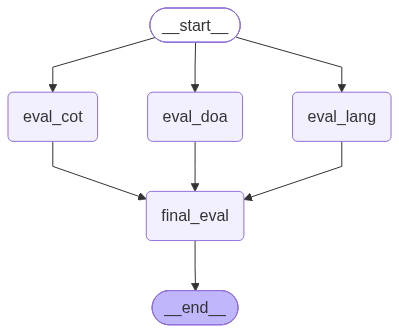

In [39]:
wf

In [40]:
essay="""Human Resource is the Most Important Resource for the Development of a Nation

Development of a country depends on many resources such as land, water, minerals, technology and capital. However, human beings are the most important resource because they are the ones who use all other resources. Without human beings, natural resources cannot be properly utilised. Therefore, human resource plays an important role in the development of a nation.

In the past, countries were mainly considered powerful based on their land, population and natural resources. But in the modern world, knowledge and skills have become equally important. Countries like Japan and Singapore have shown that a country does not necessarily need abundant natural resources to become developed. Their educated and disciplined population has helped them achieve economic growth.

Education is one of the most important ways of developing human resources. An educated person can understand new technologies, make better decisions and contribute to society. India has a large young population and this can become an advantage if proper education and training are provided. The demographic dividend can help India become a developed country.

However, having a large population alone does not mean that a country has good human resources. If people are unemployed, uneducated or unhealthy, a large population can become a burden. Therefore, governments need to focus on education, healthcare, skill development and employment opportunities.

Health is also an important part of human resource development. A person who is physically and mentally healthy can work more efficiently. Lack of healthcare can reduce productivity and increase poverty. Schemes related to health insurance, sanitation and nutrition can help in improving the quality of human resources.

Skill development is another important factor. The modern economy is changing rapidly due to artificial intelligence, automation and digital technology. Many traditional jobs are changing and new jobs are being created. Therefore, workers need to continuously improve their skills. Initiatives like Skill India can help people acquire employment-related skills.

Women are also an important part of human resources. If women do not get equal opportunities in education and employment, a country cannot fully utilise its human potential. Increasing women's participation in the workforce can increase family income as well as the overall economic growth of the country. Therefore, gender equality should be an important part of development.

Human resources are also important for innovation. Countries that invest in research, education and technology are able to develop new products and solutions. Scientists, engineers, teachers, doctors and entrepreneurs contribute to national development through their knowledge and skills. Thus, human beings are not only consumers of resources but also creators of new resources.

At the same time, human resource development faces many challenges in India. There are differences in the quality of education between rural and urban areas. Unemployment among educated youth is another major problem. There are also problems related to malnutrition, healthcare and skill mismatch. These issues need to be addressed through proper government policies and participation of the private sector.

The government alone cannot develop human resources. Educational institutions, industries, families and civil society also have important roles. Industry can provide employment and training opportunities, while educational institutions can focus on practical and relevant education. Families can encourage children to learn new skills and become responsible citizens.

In conclusion, natural resources and financial resources are important for development, but human resources are the force which converts these resources into development. A country with skilled, educated, healthy and innovative citizens can overcome many limitations. India has a large young population and therefore has a great opportunity. If this population is properly educated, skilled and provided with opportunities, it can become the biggest strength of the country. Human resource development is therefore not only an economic requirement but also the foundation of inclusive and sustainable national development."""

In [46]:

wf.invoke({'essay':essay})

{'essay': "Human Resource is the Most Important Resource for the Development of a Nation\n\nDevelopment of a country depends on many resources such as land, water, minerals, technology and capital. However, human beings are the most important resource because they are the ones who use all other resources. Without human beings, natural resources cannot be properly utilised. Therefore, human resource plays an important role in the development of a nation.\n\nIn the past, countries were mainly considered powerful based on their land, population and natural resources. But in the modern world, knowledge and skills have become equally important. Countries like Japan and Singapore have shown that a country does not necessarily need abundant natural resources to become developed. Their educated and disciplined population has helped them achieve economic growth.\n\nEducation is one of the most important ways of developing human resources. An educated person can understand new technologies, make